# Processamento de Imagens em Python: scikit-image

![](img/python-logo.png)
![](img/logo.png)


# O que é uma imagem?

![](img/pdi.png)

### Como ler uma imagem

In [1]:
#importar a funcao imread da biblioteca skimage
# pip install scikit-image
from skimage.io import imread

In [87]:
#ler imagem
imagem = imread('img/lenna.jpg')

In [88]:
imagem.shape

(220, 220, 3)

### Como mostrar uma imagem

In [4]:
#importar a biblioteca matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

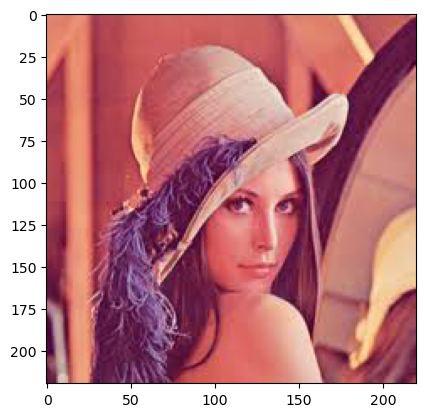

In [5]:
plt.imshow(imagem)

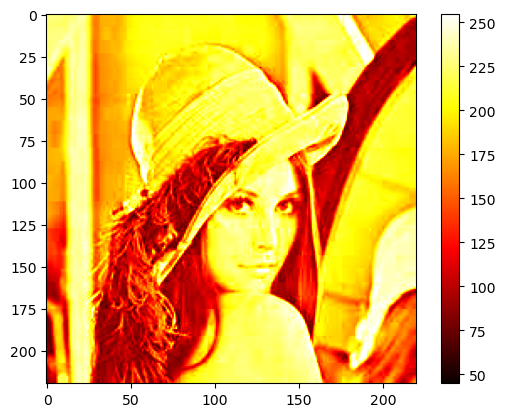

In [9]:
plt.imshow(imagem[:,:,0], cmap='hot') #mapa de calor: https://matplotlib.org/stable/users/explain/colors/colormaps.html
plt.colorbar() # Escala de cor:

### Informações da Imagem

In [10]:
#dimensões
dim = imagem.shape

In [11]:
dim

(220, 220, 3)

### Trabalhando com Imagens Coloridas (RGB)
![](img/rgb.png)

In [12]:
red = imagem[:,:,0]
green = imagem[:,:,1]
blue = imagem[:,:,2]

In [13]:
blue.shape

(220, 220)

### Mostrar várias imagens

Text(0.5, 1.0, 'Canal Blue do Sistema de Cores RGB')

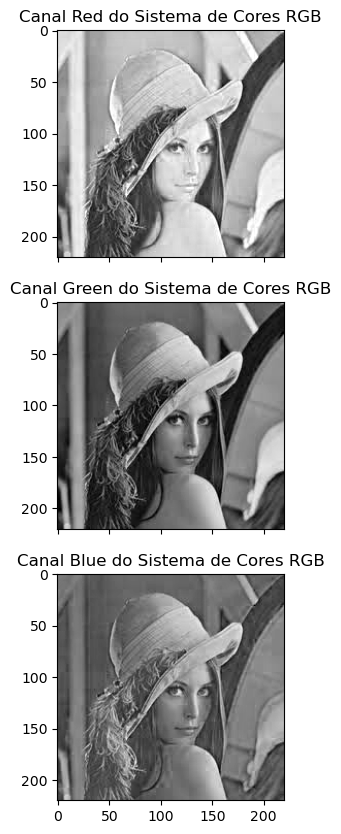

In [16]:
fig, ax = plt.subplots(3,1,figsize=(10, 10),sharex=True)
ax[0].imshow(red,cmap = 'gray')
ax[0].set_title('Canal Red do Sistema de Cores RGB')
ax[1].imshow(green,cmap = 'gray')
ax[1].set_title('Canal Green do Sistema de Cores RGB')
ax[2].imshow(blue,cmap = 'gray')
ax[2].set_title('Canal Blue do Sistema de Cores RGB')

### Níveis de cinza

$Y = 0.2125 R + 0.7154 G + 0.0721 B$

In [17]:
from skimage.color import rgb2gray

In [22]:
cinza = rgb2gray(imagem)

Text(0.5, 1.0, 'Imagens em Níveis de Cinza')

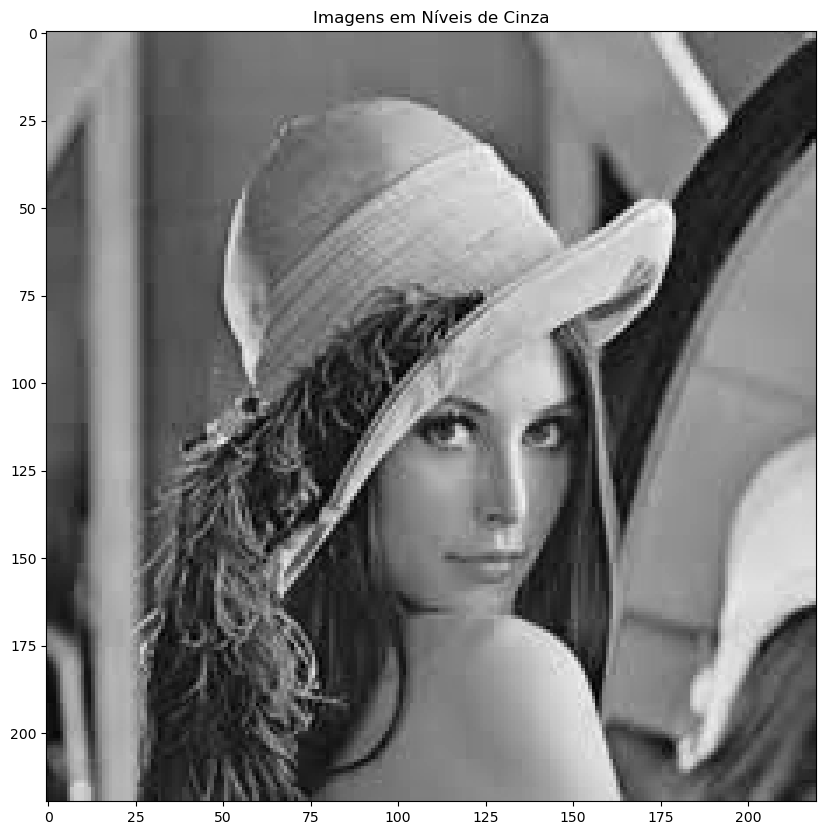

In [23]:
plt.figure(figsize=(10,10))
plt.imshow(cinza,cmap='gray')
plt.title('Imagens em Níveis de Cinza')

### Salvar resultado

In [29]:
from skimage.io import imsave
from skimage import img_as_ubyte

In [30]:
cinza_uint8 = img_as_ubyte(cinza)
imsave('img/cinza.png',cinza_uint8)

### Outros modelos de cor

In [31]:
from skimage.color import rgb2hsv
from skimage.color import rgb2lab
from skimage.color import rgb2yuv

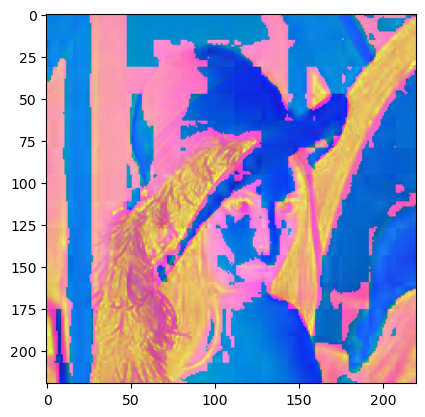

In [40]:
outromodelodecor = rgb2hsv(imagem)
plt.imshow(outromodelodecor)

## Atividade

- Leia uma imagem
- Crie variáveis para armazenar cada componente do RGB
- Salve cada imagem em disco

### Remoção de Ruídos

In [46]:
from skimage.restoration import denoise_nl_means

In [51]:
cinza_filter = denoise_nl_means(cinza,20)

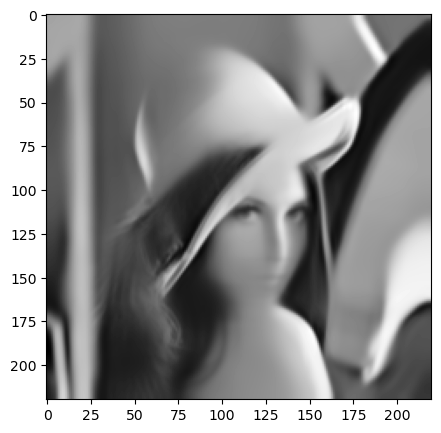

In [52]:
plt.figure(figsize=(5,5))
plt.imshow(cinza_filter,cmap = 'gray')

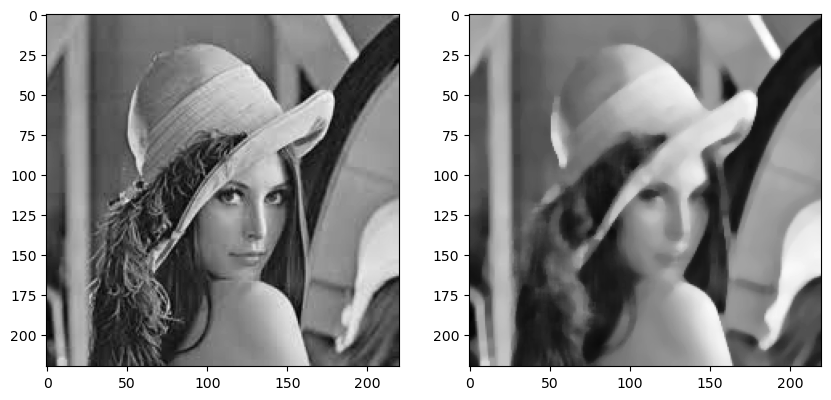

In [53]:
from skimage.filters import median
from skimage.morphology import square

im_filtrada = median(cinza,square(7))

_, ax = plt.subplots(1,2,figsize=(10,10))
ax[0].imshow(cinza,cmap='gray')
ax[1].imshow(im_filtrada,cmap='gray')

# Atividade: 

- Aplique o filtro da mediana em uma imagem de sua escolha com o tamanho de janela variando entre 3 e 13
- Plot os resultados e compare com a imagem original
- Analise os resultados obtidos

### Percorendo uma imagem

In [91]:
imagem.shape

(220, 220, 3)

In [87]:
linhas,colunas,dimensao = imagem.shape #pegar dimensoes da imagem

In [108]:
for l in range(linhas):
    for c in range(colunas):
        if (imagem[l,c,1] < 150):
            imagem[l,c,1] = 0

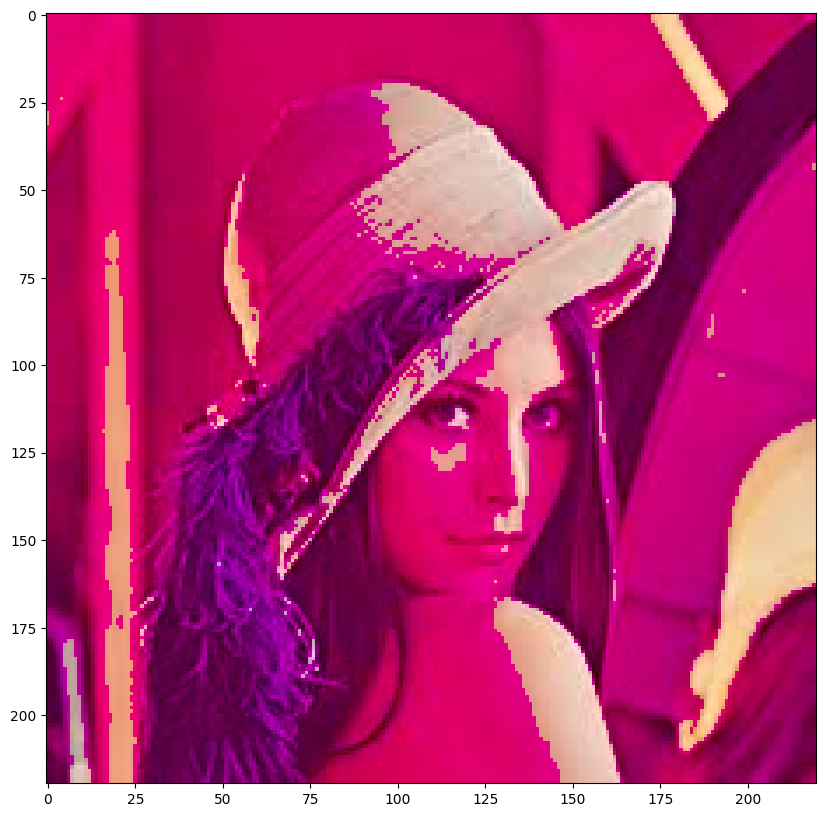

In [118]:
plt.figure(figsize=(10,10))
plt.imshow(imagem)

## Atividade 
- Percorra sua imagem e ache o pixel com maior valor em cada uma das componentes


# Imagens Preto e Branco

In [54]:
import numpy as np
from skimage.filters import threshold_otsu

In [55]:
#método de Otsu
otsu = threshold_otsu(cinza)
preto_branco = cinza < otsu

In [56]:
otsu

0.43519245404411766

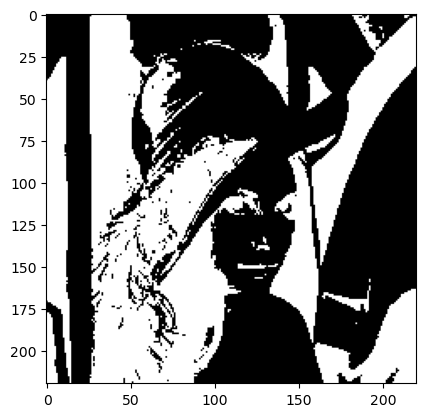

In [57]:
plt.imshow(preto_branco,cmap = 'gray')

# Atividade
- Faça uma binarização na imagem variando o limiar entre 0 e 1 com passos de 0.2
- Plot os resultados

In [183]:
# fig, ax = plt.subplots(7,1,figsize = (30,30),sharex=True)
# ax[0].imshow(cinza,cmap = 'gray')
# ax[0].set_title('Imagem Cinza')
# for idx,thr in enumerate(np.arange(0,1.1,0.2)):
#     binaria = cinza < thr
#     ax[idx+1].imshow(binaria,cmap = 'gray')
#     ax[idx+1].set_title('Imagem filtrada com janela '+str(thr))

### Encontrando Bordas

In [59]:
from skimage.filters import sobel,roberts,prewitt,scharr

In [68]:
contorno = sobel(preto_branco)

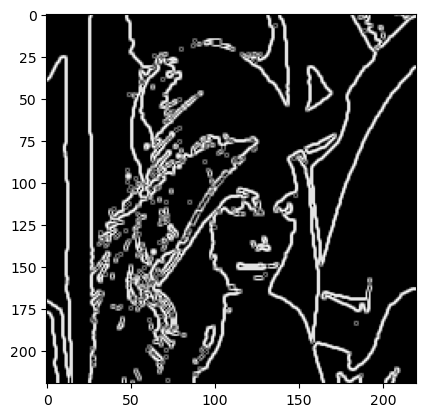

In [69]:
plt.imshow(contorno,cmap = 'gray')

## Atividade
- Transforme uma imagem para preto e branco
- Utilize outros métodos que não seja o de Sobel para encontrar as bordas. Ex: scharr, prewitt e roberts
- Faça um plot com todos os métodos que você utilizou

### Recortes em Imagens

In [70]:
imagem = imread('img/lenna.jpg')
imagem.shape

(220, 220, 3)

In [71]:
recorte_imagem = imagem[60:170,80:160,:]

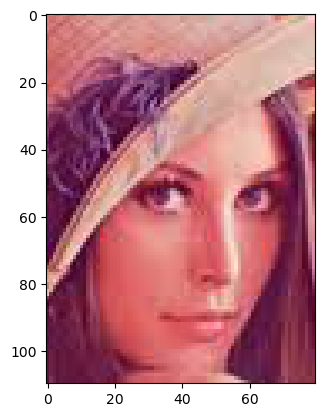

In [72]:
plt.imshow(recorte_imagem)

## Histograma: 
- é uma das ferramentas mais simples e úteis para o PDI;
- é uma função que mostra a frequência com que um nível de cinza aparece na imagem;
- a exibição gráfica do histograma para todos os valores de níveis de cinza K providencia uma descrição global de uma imagem.

In [75]:
import numpy as np
from skimage.io import imread,imsave
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
%matplotlib inline

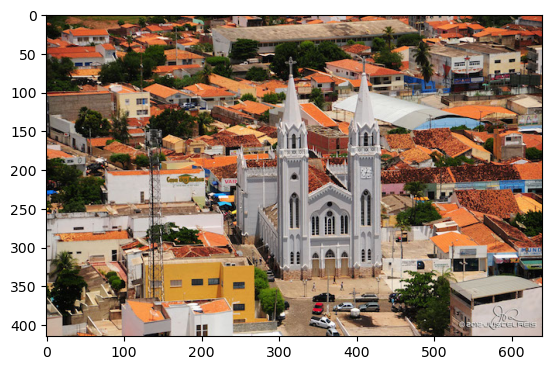

In [76]:
imagem = imread('img/picos.jpg')
plt.imshow(imagem)

In [77]:
claro = imread("img/picos_claro.jpg")
escuro = imread("img/picos_escuro.jpg")
medio = imread("img/picos_medio.jpg")
nitido = imread("img/picos_nitido.jpg")

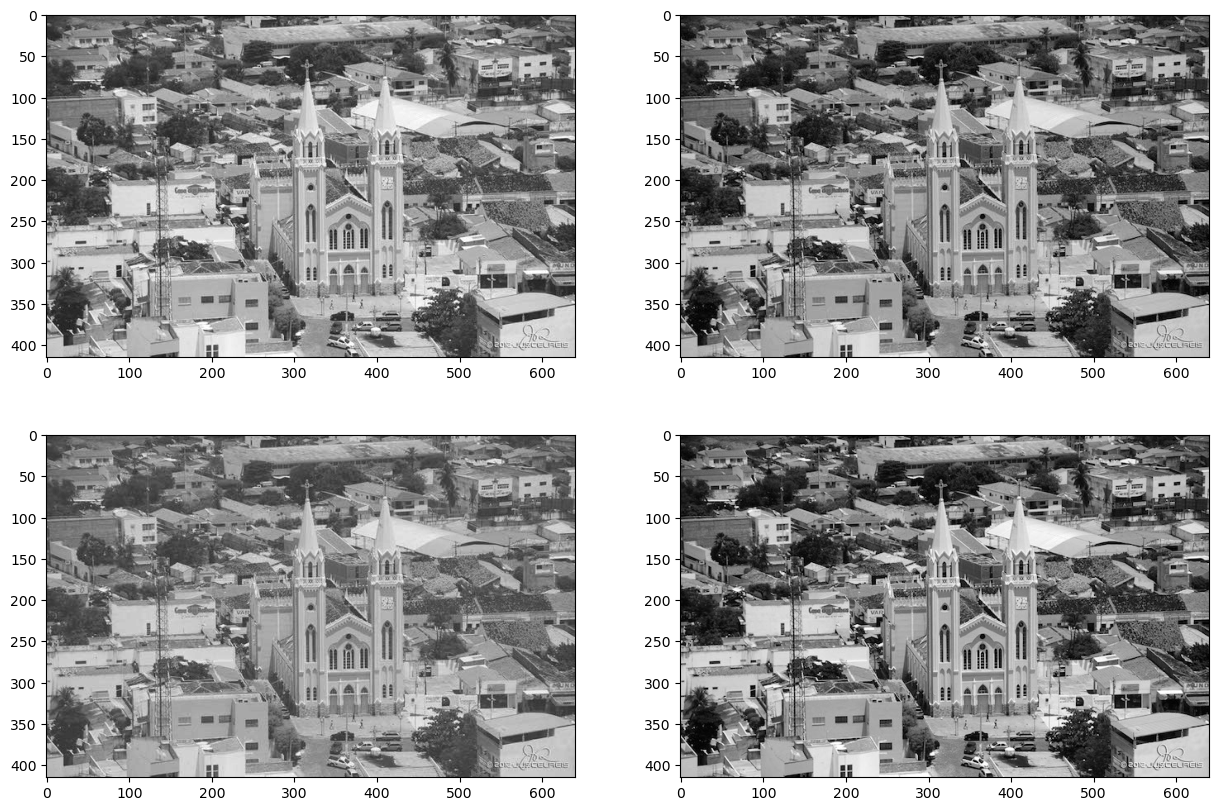

In [78]:
fig,ax = plt.subplots(2,2,figsize=(15,10))
ax[0,0].imshow(claro,cmap = "gray")
ax[0,1].imshow(escuro,cmap = "gray")
ax[1,0].imshow(medio,cmap = "gray")
ax[1,1].imshow(nitido,cmap = "gray")

### Como calcular o histograma de uma imagem

In [79]:
from skimage.exposure import histogram

In [80]:
hist_claro = histogram(claro,nbins=256)
hist_escuro = histogram(escuro,nbins=256)
hist_medio = histogram(medio,nbins=256)
hist_nitido = histogram(nitido,nbins=256)

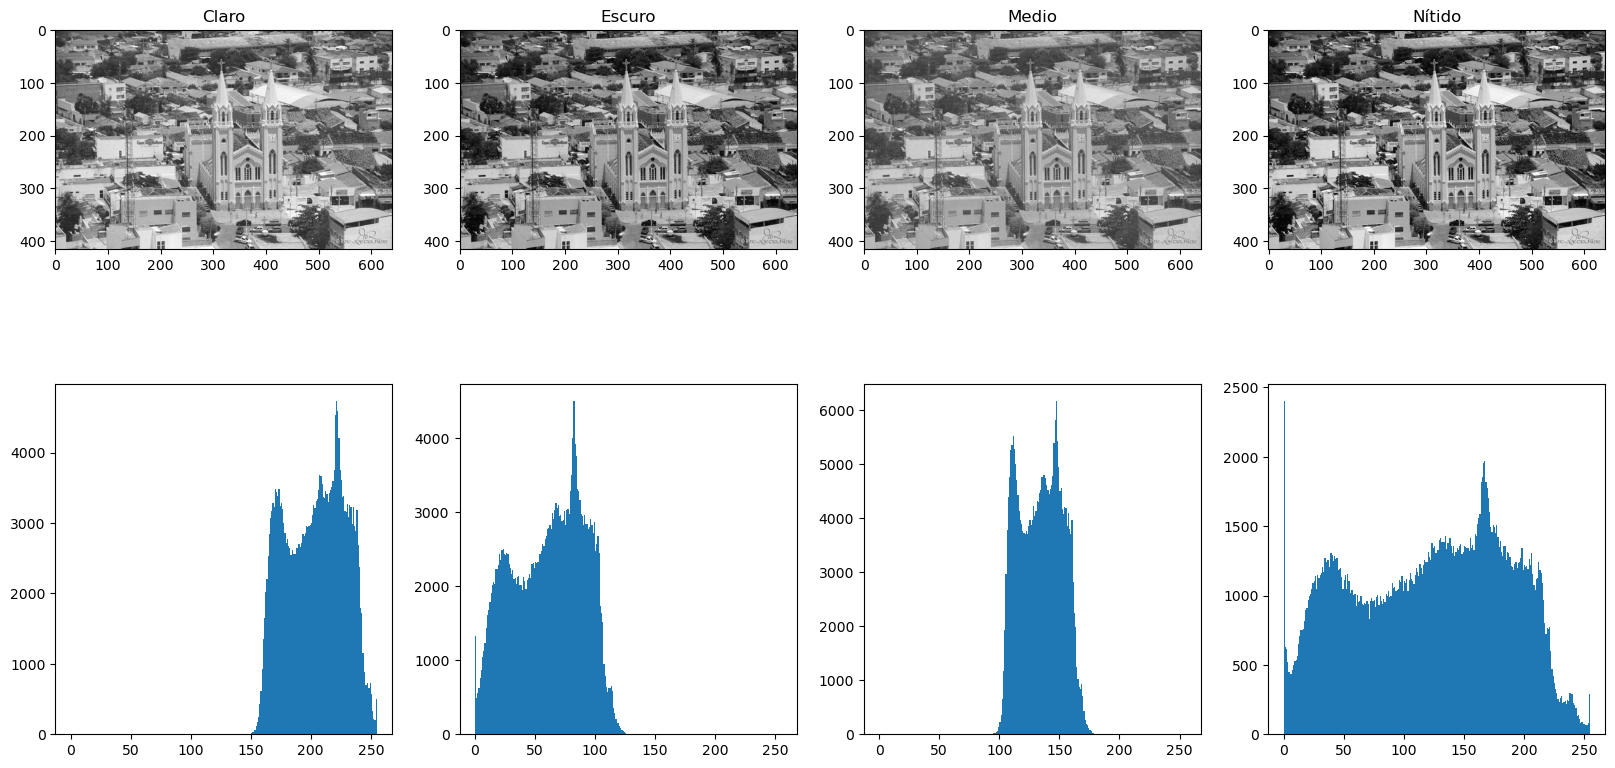

In [82]:
fig,ax = plt.subplots(2,4,figsize=(20,10))
ax[0,0].imshow(claro,cmap = "gray")
ax[0,0].set_title('Claro')
ax[0,1].imshow(escuro,cmap = "gray")
ax[0,1].set_title('Escuro')
ax[0,2].imshow(medio,cmap = "gray")
ax[0,2].set_title('Medio')
ax[0,3].imshow(nitido,cmap = "gray")
ax[0,3].set_title('Nítido')
ax[1,0].hist(claro.ravel(),range(256))
ax[1,1].hist(escuro.ravel(),range(256))
ax[1,2].hist(medio.ravel(),range(256))
ax[1,3].hist(nitido.ravel(),range(256));

#### Processamento de Histograma:

- Um histograma pode ser visto como uma função de distribuição de frequência ou como uma função de distribuição de probabilidade;

$$p(r_k)=\frac{n_k}{n}.$$

- De maneira geral dizemos que $p(r_k)$ dá uma estimativa da probabilidade de ocorrência do nível de cinza $r_k$ na imagem.

#### Propriedade do histograma:

- As informações espaciais não são representadas;

- Um histograma é único para uma determinada imagem, mas o inverso não é verdadeiro;

- A movimentação de objetos em uma imagem não tem qualquer efeito sobre o seu histograma.

## Equalização de histograma

- É uma transformação dos níveis de cinza de uma imagem que visa aumentar o intervalo dinâmico melhorando o contraste de imagens adquiridas sob péssimas condições de iluminação;
- É útil para comparar cenas que foram adquiridas com iluminação diferente (normaliza a imagem);
- De modo geral o que se procura é obter um histograma plano.

In [84]:
from skimage.exposure import equalize_hist

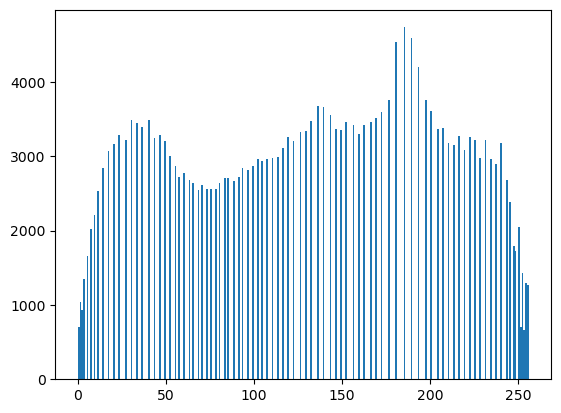

In [85]:
new_claro = equalize_hist(claro)
plt.hist(new_claro.ravel()*256,bins=256);

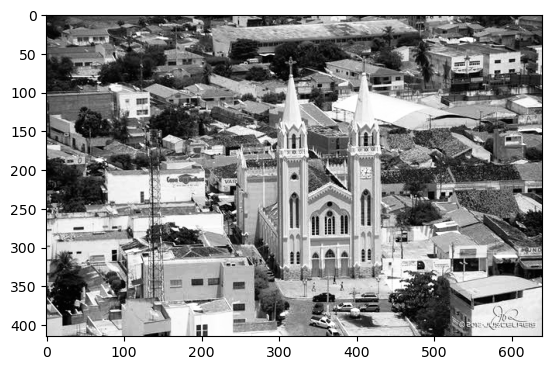

In [86]:
plt.imshow(new_claro,cmap='gray')

# Atividade

Mostre as imagens antes e depois da equalização

### Atributos de Textura de 1$^a$ ordem

Os seguintes valores são calculado com o histograma e são largamente utilizados para representar imagens:
- Média
- Variância
- Skewness
- Kurtosis
- Energia
- Entropia

# Atividade: 
Implementar os atributos acima em uma imagem.